In [479]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [480]:
id_list = [925, 165, 9, 477, 291, 162] #InfraRed = 925, concrete = 165, Auto MPG = 9, 
        #Real estate valuation = 477, Air-foil self-noise = 291, forest fires = 162

In [481]:
nr_of_seeds = 30 #nr of seeds in the experiments
index = 165

In [482]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [483]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [484]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_9192\2895359420.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_9192\2895359420.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_9192\2895359420.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

<Axes: xlabel='method', ylabel='rmse'>

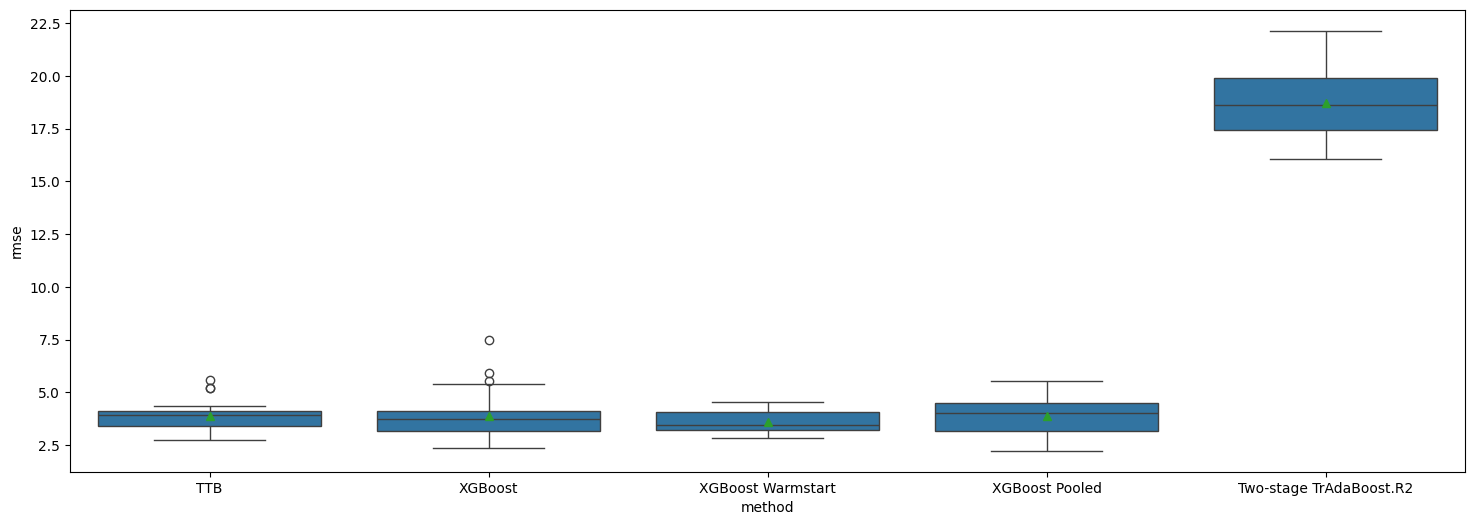

In [485]:
plt.figure(figsize = (18,6))
#Boxplot
dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
#dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'


data = pd.read_csv(f'results/xgb_warmstart_{index}.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
    xgboost_data_warmstart,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results/xgb_naive_{index}.csv')
xgboost_data_pooled = data
xgboost_data_pooled['method'] = 'XGBoost Pooled'

best_XGBoost_pooled, best_XGBoost_params_pooled = topk_per_d_per_method(
    xgboost_data_pooled,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results/two_trada_{index}.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators'], k=nr_of_seeds
)
best_trada['method'] = 'Two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
#df = best_XGBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_XGBoost_pooled])
df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [486]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
44,0.1,1.0,3.0,0.01,0.9,3.876792,30,860.0,400.0,2.265634,1.743137,3.565327,2.456633,TransferTreeBoost


In [487]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
27,0.3,3.0,3.90153,30,32,860.0,4.129883,3.047704,3.798811,2.985926,XGBoost


In [488]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1050,0.25,3.0,3.596312,30,1070,889.0,3.726681,2.370949,3.560505,2.373607,XGBoost Warmstart


In [489]:
#Get best params in order
best_XGBoost_params_pooled.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
328,0.2,6.0,3.875386,30,347,869.0,4.839682,3.552643,2.790859,2.175266,XGBoost Pooled


In [490]:
best_trada_params.iloc[::nr_of_seeds]

,lr,n_estimators,avg_rmse,n_seeds,Unnamed: 0,seed,rmse,mae,method
884,1.0,150.0,18.735208,30,899,889.0,20.04966,16.816219,two-stage TrAdaBoost.R2


In [491]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(0.6340448034336021)

In [492]:
l = [7.3393227538710155, 4.735811459752751, 4.979078149374135, 1.164187085102093, 1.0248113183095346, 1.7660984951885783, 12.368571357630206]
import numpy as np
np.mean(l)

np.float64(4.768268659889759)